# 02 — The α question

**Third of five.** Findings **F3** and **F4**.

The entropia paper's central object is a **Rényi entropy of order α**. It reports
α = 0.6 as optimal. The replication swept α across a 25-fold range and found the
whole range inside noise.

Before that can mean anything you have to know what the knob does — so this
notebook is in two halves.

1. **What α is.** Computed and plotted here, on distributions you can see. By the
   end of §2 you should know what changing α does to a number, and to a
   distribution, without being told the answer.
2. **Why it did not move.** The measured sweep, the noise floor it must be read
   against, and — the intellectual core of the whole series — a simulation
   showing that a sweep with one run per condition manufactures a clean optimum
   out of nothing at all.

Then **F4**: the paper's own novelty, tested against the ablation that isolates
it, and the general lesson that follows.

### Running this notebook

Pinned to the kernel `ext-research` — the `.venv` beside the project. Register it
once, from the repository root:

```bash
02-ext-research/.venv/bin/python -m ipykernel install \
    --user --name ext-research --display-name "Python (02-ext-research)"
```

**It runs on a clean checkout with no data and no results.** `.gitignore` excludes
`results/` at every level, and the corpora are gigabytes behind author
applications, so nothing here reads `data/` or `results/`. Measured numbers are
**hard-coded as verified constants** in the cell below, each carrying the file it
came from and the line of
`01-info-propagation/overview/EVIDENCE-INDEX.md` that records it. Everything else
is computed live on synthetic data, in front of you.

The notebook is a **build artefact** of `scripts/build_ext_02_notebook.py`.
Edit the builder, not the `.ipynb`, or your changes are lost on the next
regeneration.

In [1]:
# --- Setup -----------------------------------------------------------------
# OMP_NUM_THREADS must be set BEFORE the first scikit-learn / numpy-BLAS import.
# On this machine the default OpenMP pool cost 133x wall time on a 4,770 x 12
# fit -- pure scheduling overhead, measured in bitacora/04_p2_temporal.md sect. 6.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42

# --- Palette ---------------------------------------------------------------
# One palette across all five notebooks. Colour-blind safe: validated with the
# dataviz skill's checker (worst adjacent-pair CVD delta-E 9.1, normal-vision
# 22.9, both above their floors). Hues are assigned in fixed slot order and
# never cycled; colour never carries identity alone -- every series is also
# labelled directly or in a legend.
C = {
    "blue":    "#2a78d6",   # slot 1 -- the thing under test
    "orange":  "#eb6834",   # slot 2 -- its comparison / the other class
    "aqua":    "#1baf7a",   # slot 3 -- a third series
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "violet":  "#4a3aa7",   # slot 6
    "red":     "#e34948",   # reserved: floors, baselines, failures
    "grey":    "#8a8a86",   # recessive: grids, noise bands, context
    "ink":     "#0b0b0b",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["violet"]]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c9c4", "axes.labelcolor": C["ink"],
    "axes.grid": True, "grid.color": "#e3e3de", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": C["ink"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True, linewidth=110)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__}")
print(f"OMP_NUM_THREADS={os.environ['OMP_NUM_THREADS']}  seed={SEED}")

numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1
OMP_NUM_THREADS=1  seed=42


---

## 1. Rényi entropy, from the definition

For a probability distribution $p = (p_1, \dots, p_k)$ and an order
$\alpha \ge 0$, $\alpha \ne 1$:

$$H_\alpha(p) \;=\; \frac{1}{1-\alpha}\,\log_2\!\Big(\sum_i p_i^{\alpha}\Big)$$

Four orders have names, and each is a different question about the distribution:

| order | value | the question it answers |
|---|---|---|
| $H_0$ | $\log_2 \lvert\{i : p_i > 0\}\rvert$ | **support richness** — how many outcomes are possible at all? Ignores probabilities entirely. |
| $H_1$ | $-\sum_i p_i \log_2 p_i$ | **Shannon** — the average surprise. The $\alpha \to 1$ limit, taken in closed form because $1/(1-\alpha)$ blows up. |
| $H_2$ | $-\log_2 \sum_i p_i^2$ | **collision entropy** — how likely are two independent draws to be equal? A repetition statistic. |
| $H_\infty$ | $-\log_2 \max_i p_i$ | **min-entropy** — governed entirely by the single most likely outcome. |

Between them, the family interpolates: **low α weights the tail** (rare outcomes
count), **high α weights the mode** (the peak dominates). Three facts hold for
every distribution, and they are worth stating because they are what make the
curve readable:

- $H_\alpha$ is **non-increasing** in α;
- $H_0 \ge H_1 \ge H_2 \ge H_\infty$;
- for the **uniform** distribution on $n$ points, $H_\alpha = \log_2 n$ for
  *every* α — a flat curve. Any curvature at all is a departure from uniformity.

In [2]:
# --- Rényi entropy in eight lines ------------------------------------------
# Base 2 (bits) throughout. Plug-in estimator, no bias correction -- the limits
# at 0, 1 and infinity are taken in CLOSED FORM, because 1/(1-alpha) is singular
# at alpha = 1 and the naive expression loses all precision near it.
def renyi(p, alpha):
    p = np.asarray(p, float)
    p = p[p > 0]
    p = p / p.sum()
    if np.isinf(alpha):
        return float(-np.log2(p.max()))            # min-entropy
    if alpha == 0.0:
        return float(np.log2(p.size))              # log support
    if abs(alpha - 1.0) < 1e-8:
        return float(-(p * np.log2(p)).sum())      # Shannon
    return float(np.log2((p ** alpha).sum()) / (1.0 - alpha))

# Sanity: the properties above, checked rather than asserted.
u = np.ones(16) / 16
print("uniform on 16 points, H_alpha for alpha = 0, 0.5, 1, 2, 4, inf:")
print("  ", [round(renyi(u, a), 6) for a in (0, 0.5, 1, 2, 4, np.inf)],
      " -> log2(16) =", np.log2(16), "everywhere, as required")

q = np.array([0.7, 0.2, 0.05, 0.03, 0.02])
vals = [renyi(q, a) for a in (0, 0.5, 1, 2, 4, np.inf)]
print("\nskewed distribution, same orders:")
print("  ", [round(v, 4) for v in vals])
print("   non-increasing?", all(vals[i] >= vals[i + 1] - 1e-12 for i in range(len(vals) - 1)))

uniform on 16 points, H_alpha for alpha = 0, 0.5, 1, 2, 4, inf:
   [4.0, 4.0, 4.0, 4.0, 4.0, 4.0]  -> log2(16) = 4.0 everywhere, as required

skewed distribution, same orders:
   [2.3219, 1.7312, 1.3053, 0.9056, 0.6829, 0.5146]
   non-increasing? True


## 2. What the knob does — four distributions on one axis

Four distributions on 32 outcomes, chosen to be different *in shape* rather than
in size:

- **uniform** — every outcome equally likely;
- **heavy-tailed** — Zipf, $p_i \propto i^{-1}$: a few common outcomes and a long
  tail of rare ones;
- **near-degenerate** — one outcome at 0.90, the remaining 0.10 spread over 31;
- **bimodal** — two outcomes at 0.35 each, the rest sharing 0.30.

In [3]:
# --- Four distributions, and their alpha-curves ----------------------------
K = 32
dists = {}
dists["uniform"]        = np.ones(K)
dists["heavy-tailed (Zipf)"] = 1.0 / np.arange(1, K + 1)
near = np.full(K, 0.10 / (K - 1)); near[0] = 0.90
dists["near-degenerate"] = near
bim = np.full(K, 0.30 / (K - 2)); bim[0] = bim[1] = 0.35
dists["bimodal"]         = bim
dists = {k: v / v.sum() for k, v in dists.items()}

ALPHAS = np.concatenate([np.linspace(0.0, 6.0, 121), [np.inf]])
curves = {k: np.array([renyi(v, a) for a in ALPHAS]) for k, v in dists.items()}

named = pd.DataFrame({k: [renyi(v, a) for a in (0, 1, 2, np.inf)]
                      for k, v in dists.items()},
                     index=["H_0 (log support)", "H_1 (Shannon)",
                            "H_2 (collision)", "H_inf (min-entropy)"])
print("All four live on 32 outcomes, so H_0 = log2(32) = 5.0 for every one of them.")
print("Everything that distinguishes them is what happens as alpha rises.\n")
print(named.round(3).to_string())

All four live on 32 outcomes, so H_0 = log2(32) = 5.0 for every one of them.
Everything that distinguishes them is what happens as alpha rises.

                     uniform  heavy-tailed (Zipf)  near-degenerate  bimodal
H_0 (log support)        5.0                5.000            5.000    5.000
H_1 (Shannon)            5.0                4.149            0.964    3.053
H_2 (collision)          5.0                3.351            0.303    2.012
H_inf (min-entropy)      5.0                2.021            0.152    1.515


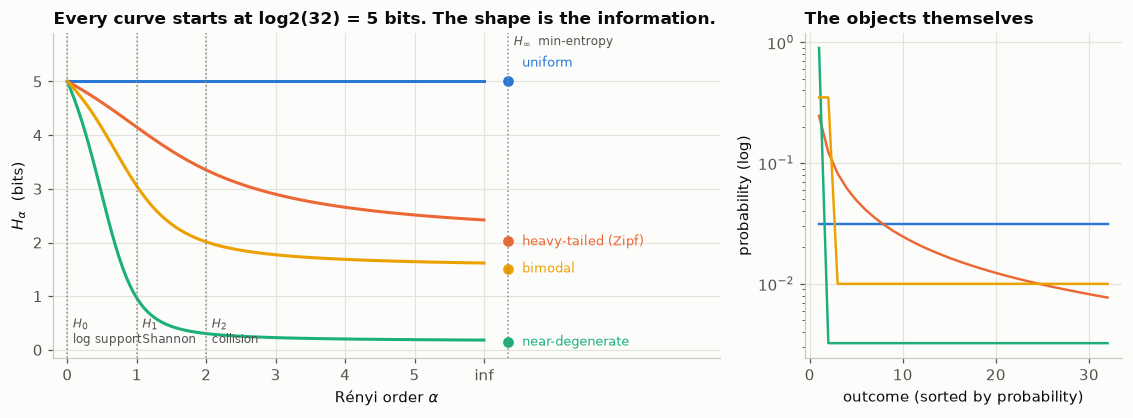

In [4]:
# --- Chart: the alpha-curves, with the named orders annotated --------------
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9),
                         gridspec_kw={"width_ratios": [2.1, 1]})

ax = axes[0]
fin = np.isfinite(ALPHAS)
for (name, y), col in zip(curves.items(), SERIES):
    ax.plot(ALPHAS[fin], y[fin], color=col, label=name)
    ax.plot([6.35], [y[-1]], "o", color=col, ms=6)          # H_inf, plotted off-grid
    lab_y = 5.35 if name == "uniform" else y[-1]            # nudge the flat one clear
    ax.text(6.55, lab_y, name, color=col, fontsize=8.5, va="center")
for a, lab in [(0, "$H_0$\nlog support"), (1, "$H_1$\nShannon"),
               (2, "$H_2$\ncollision")]:
    ax.axvline(a, color=C["grey"], lw=1, ls=":")
    ax.text(a + 0.08, 0.05, lab, fontsize=8, color="#52514e", va="bottom")
ax.axvline(6.35, color=C["grey"], lw=1, ls=":")           # H_inf, labelled at the top
ax.text(6.43, 5.85, "$H_\\infty$  min-entropy", fontsize=8, color="#52514e", va="top")
ax.set_xlim(-0.2, 9.4); ax.set_ylim(-0.15, 5.9)
ax.set_xticks([0, 1, 2, 3, 4, 5, 6]); ax.set_xticklabels(["0", "1", "2", "3", "4", "5", "inf"])
ax.set_xlabel("Rényi order $\\alpha$")
ax.set_ylabel("$H_\\alpha$  (bits)")
ax.set_title("Every curve starts at log2(32) = 5 bits. The shape is the information.")

ax = axes[1]
w = 0.8
for (name, p), col in zip(dists.items(), SERIES):
    ax.plot(np.arange(1, K + 1), np.sort(p)[::-1], color=col, lw=1.6)
ax.set_yscale("log"); ax.set_xlabel("outcome (sorted by probability)")
ax.set_ylabel("probability (log)")
ax.set_title("The objects themselves")
plt.tight_layout(); plt.show()

**Figure 1.** The reader should conclude that **α is a knob for how much the tail
counts**. All four distributions have identical support, so identical $H_0$; they
separate only as α rises and the mode starts to dominate. The near-degenerate
distribution (one outcome at 0.90) falls almost immediately, because $H_\infty$
sees only that peak. The uniform one never falls at all. Right panel: the objects
the curves summarise, drawn so you can check the summary against the thing.

*(Datasaurus rule, applied to ourselves: an α-curve is a plot of a **statistic**.
The distribution is the **object**. Both get drawn.)*

### Escort distributions — making "α reweights the tail" concrete

The mechanism has a name. The **escort distribution** of order α is

$$p^{(\alpha)}_i \;=\; \frac{p_i^{\alpha}}{\sum_j p_j^{\alpha}}$$

and $H_\alpha$ is, up to normalisation, an entropy computed in this reweighted
world. At α < 1 the escort **flattens** the distribution, lifting rare outcomes.
At α > 1 it **sharpens** it, until at α → ∞ all the mass sits on the mode. This
is the single most useful mental picture of what the order does.

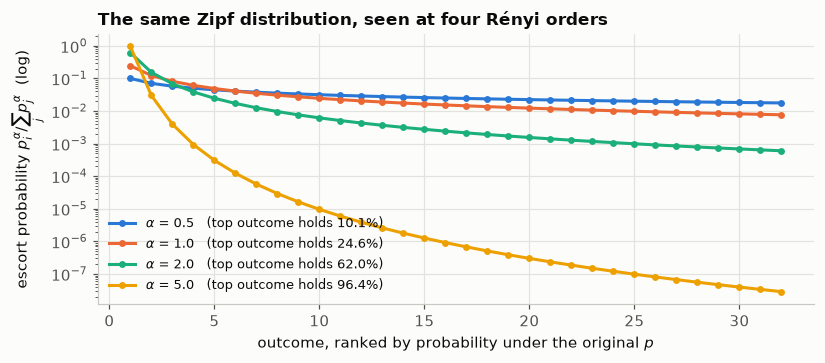

In [5]:
# --- Escort distributions of the heavy-tailed case -------------------------
def escort(p, alpha):
    p = np.asarray(p, float)
    w = p ** alpha
    return w / w.sum()

p0 = dists["heavy-tailed (Zipf)"]
fig, ax = plt.subplots(figsize=(7.6, 3.4))
for a, col in zip([0.5, 1.0, 2.0, 5.0], SERIES):
    e = escort(p0, a)
    ax.plot(np.arange(1, K + 1), e, color=col, marker="o", ms=3.5,
            label=f"$\\alpha$ = {a}   (top outcome holds {e[0]:.1%})")
ax.set_yscale("log")
ax.set_xlabel("outcome, ranked by probability under the original $p$")
ax.set_ylabel("escort probability $p_i^{\\alpha} / \\sum_j p_j^{\\alpha}$  (log)")
ax.set_title("The same Zipf distribution, seen at four Rényi orders")
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Figure 2.** One distribution, four views. At α = 0.5 the curve is nearly flat —
the tail has been lifted into relevance. At α = 5 the top outcome holds most of
the mass and the tail has been erased. **This is why α is a genuinely useful
degree of freedom when the distributions you are comparing differ in their
tails** — and it is also why it will do nothing when they do not. Hold that
sentence; it is the whole of F3.

---

## 3. F3 — α on the task it was introduced for

### Where α enters the entropia pipeline

For each node $v$ in a temporal snapshot of a message graph, the paper forms the
distribution $p_u \propto \deg(u)$ over $v$'s **neighbours**, and takes
$H_\alpha$ of it. That entropy is one feature block inside a 67-dimensional
GraphSAGE link-prediction pipeline on CollegeMsg. The paper reports α = 0.6 as
optimal (Sect. 4.2.1).

Now look at the object before looking at the result. How many points does that
distribution have?

In [6]:
# --- The substrate: a neighbourhood degree distribution has very few points
# CollegeMsg-like: most nodes have a handful of neighbours. What can alpha
# resolve on a distribution with 3 points, versus one with 500?
g = np.random.default_rng(SEED)

def alpha_range(p, lo=0.2, hi=5.0):
    """How much H_alpha moves across the swept range -- alpha's total leverage."""
    v = [renyi(p, a) for a in np.linspace(lo, hi, 40)]
    return max(v) - min(v)

rows = []
for k in [3, 5, 10, 20, 100, 500]:
    # neighbour degrees drawn from a heavy-tailed degree distribution
    reps = [alpha_range(g.pareto(1.5, size=k) + 1.0) for _ in range(400)]
    rows.append((k, float(np.mean(reps)), float(np.std(reps)), float(np.log2(k))))
SUBSTRATE = pd.DataFrame(rows, columns=["n_neighbours", "alpha_leverage_bits",
                                        "sd", "H_0 = log2(n)"])
print("How many bits does moving alpha from 0.2 to 5 buy you, as a function of")
print("how many points the distribution has?  (heavy-tailed degrees, 400 draws each)\n")
print(SUBSTRATE.round(3).to_string(index=False))

How many bits does moving alpha from 0.2 to 5 buy you, as a function of
how many points the distribution has?  (heavy-tailed degrees, 400 draws each)

 n_neighbours  alpha_leverage_bits    sd  H_0 = log2(n)
            3                0.380 0.324          1.585
            5                0.634 0.465          2.322
           10                1.057 0.617          3.322
           20                1.517 0.738          4.322
          100                2.690 1.021          6.644
          500                3.993 1.201          8.966


α needs points to work with. On a distribution over 3 to 20 neighbours — which is
what most nodes in a message graph have — there is very little tail for α to
resolve, and $H_\alpha$ is dominated by the support size, which is just the
degree of $v$. **α is being asked to distinguish shapes in objects that barely
have a shape.**

That is a statement about the *substrate*, not about Rényi entropy. Keep it
separate from the measurement that follows, because notebook 04 shows the same
family behaving differently on a substrate with hundreds of points per unit.

### The measurement

In [7]:
# --- Verified constants: the alpha sweep -----------------------------------
# Source: results/alpha_sweep.json -- CollegeMsg link prediction, 3 seeds.
# EVIDENCE-INDEX.md sect. 4, full precision.
ALPHA_SWEEP = pd.DataFrame([
    (0.2, 0.8409060244215071, 0.0075607555040802, 0.7934272300469484, 0.0108845287505819),
    (0.6, 0.8348343790055995, 0.0050061820933320, 0.7417840375586854, 0.0423837325945253),
    (1.0, 0.8359812453619376, 0.0062849505214493, 0.7687793427230046, 0.0092417932793566),
    (1.5, 0.8390845307967348, 0.0090756801810655, 0.7500000000000000, 0.0377051136249038),
    (2.0, 0.8329116912905620, 0.0079738474594151, 0.7417840375586854, 0.0418933528112083),
    (5.0, 0.8311070633475005, 0.0059577170191791, 0.7464788732394366, 0.0505376763887582),
], columns=["alpha", "auc", "auc_std", "accuracy", "accuracy_std"])

# The noise floor: the SAME pipeline over 10 seeds, DTWRE configuration.
# Source: results/significance_auc.json, dtwre row SD. EVIDENCE-INDEX.md sect. 5.
SEED_SIGMA = 0.0179144

spread = ALPHA_SWEEP.auc.max() - ALPHA_SWEEP.auc.min()   # 0.0097989610740066
print("CollegeMsg link prediction, 3 seeds.  Metric is AUC, so chance = 0.5.")
print(ALPHA_SWEEP.round(4).to_string(index=False))
print()
print(f"total AUC spread across a 25-fold range of alpha : {spread:.4f}")
print(f"seed-to-seed sigma of the same pipeline (10 seeds): {SEED_SIGMA:.4f}")
print(f"the entire alpha effect, in standard deviations   : {spread / SEED_SIGMA:.2f} sigma")
print()
print(f"replication's best alpha : {ALPHA_SWEEP.loc[ALPHA_SWEEP.auc.idxmax(), 'alpha']}")
print(f"paper's stated optimum   : 0.6")

CollegeMsg link prediction, 3 seeds.  Metric is AUC, so chance = 0.5.
 alpha    auc  auc_std  accuracy  accuracy_std
   0.2 0.8409   0.0076    0.7934        0.0109
   0.6 0.8348   0.0050    0.7418        0.0424
   1.0 0.8360   0.0063    0.7688        0.0092
   1.5 0.8391   0.0091    0.7500        0.0377
   2.0 0.8329   0.0080    0.7418        0.0419
   5.0 0.8311   0.0060    0.7465        0.0505

total AUC spread across a 25-fold range of alpha : 0.0098
seed-to-seed sigma of the same pipeline (10 seeds): 0.0179
the entire alpha effect, in standard deviations   : 0.55 sigma

replication's best alpha : 0.2
paper's stated optimum   : 0.6


In [8]:
# --- Verified constants: the paper's own published sweep -------------------
# Source: dtwre/config.py, PAPER_ALPHA_AUC, transcribed from Sect. 4.2.1.
# EVIDENCE-INDEX.md sect. 4, "Published comparison".
PAPER_ALPHA_AUC = {0.2: 0.950, 0.6: 0.966, 1.0: 0.959, 1.5: 0.955, 2.0: 0.952, 5.0: 0.944}
paper_spread = max(PAPER_ALPHA_AUC.values()) - min(PAPER_ALPHA_AUC.values())
print(f"published spread : {paper_spread:.3f}")
print(f"measured sigma   : {SEED_SIGMA:.4f}")
print(f"i.e. the paper's own alpha effect is {paper_spread / SEED_SIGMA:.1f} sigma,")
print("reported from a protocol with no seeds, no repetitions and no error bars.")

published spread : 0.022
measured sigma   : 0.0179
i.e. the paper's own alpha effect is 1.2 sigma,
reported from a protocol with no seeds, no repetitions and no error bars.


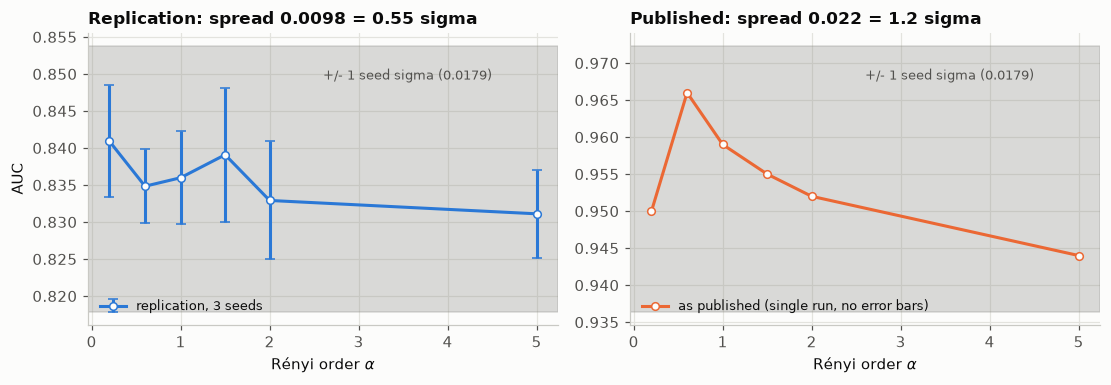

In [9]:
# --- Chart: both sweeps, each against the noise floor ----------------------
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharex=True)

ax = axes[0]
ax.errorbar(ALPHA_SWEEP.alpha, ALPHA_SWEEP.auc, yerr=ALPHA_SWEEP.auc_std,
            fmt="o-", color=C["blue"], ms=5, mfc="#fcfcfb", capsize=3,
            label="replication, 3 seeds")
mid = ALPHA_SWEEP.auc.mean()
ax.axhspan(mid - SEED_SIGMA, mid + SEED_SIGMA, color=C["grey"], alpha=0.30)
ax.text(2.6, mid + SEED_SIGMA * 0.75, "+/- 1 seed sigma (0.0179)", fontsize=8.5,
        color="#52514e")
ax.set_ylabel("AUC"); ax.set_xlabel("Rényi order $\\alpha$")
ax.set_title(f"Replication: spread {spread:.4f} = {spread/SEED_SIGMA:.2f} sigma")
ax.legend(loc="lower left", fontsize=8.5)

ax = axes[1]
pa = np.array(sorted(PAPER_ALPHA_AUC.items()))
ax.plot(pa[:, 0], pa[:, 1], "o-", color=C["orange"], ms=5, mfc="#fcfcfb",
        label="as published (single run, no error bars)")
pm = pa[:, 1].mean()
ax.axhspan(pm - SEED_SIGMA, pm + SEED_SIGMA, color=C["grey"], alpha=0.30)
ax.text(2.6, pm + SEED_SIGMA * 0.75, "+/- 1 seed sigma (0.0179)", fontsize=8.5,
        color="#52514e")
ax.set_xlabel("Rényi order $\\alpha$")
ax.set_title(f"Published: spread {paper_spread:.3f} = {paper_spread/SEED_SIGMA:.1f} sigma")
ax.legend(loc="lower left", fontsize=8.5)

plt.tight_layout(); plt.show()

**Figure 3.** Both panels show the noise band the same pipeline actually has,
drawn to scale. Left: the replication's entire α effect fits inside half a
standard deviation, and its argmax (α = 0.2) is not the paper's stated optimum.
Right: the published curve looks like a clean peak at α = 0.6, and it is 1.2 σ
tall — measured from a protocol that reports no seeds, no repetitions and no
error bars anywhere.

**The important point does not require our replication to be right about
anything else.** A single-run sweep cannot distinguish a 0.022 effect from
run-to-run variation, and the paper provides nothing with which to try. That is a
statement about the design, not about the result.

---

## 4. The core of this series — what a single-run sweep looks like when nothing is there

This section is a simulation, not a measurement, and it is the most transferable
thing in the five notebooks.

**Set-up.** Six conditions — call them six values of α. Suppose the truth is that
**they are all identical**: no effect whatsoever. Each run of the pipeline
carries independent noise with σ = 0.018, the seed-to-seed σ actually measured
on this pipeline. Run each condition **once**, as the paper did, and plot the
result.

In [10]:
# --- Simulation: six conditions, no effect, one run each -------------------
# sigma is the MEASURED seed-to-seed sigma of the entropia pipeline (0.0179).
TRUE_AUC = 0.955       # the same value for all six conditions, by construction
SIGMA    = 0.0179144   # results/significance_auc.json, dtwre row SD
ALPHA_GRID = np.array([0.2, 0.6, 1.0, 1.5, 2.0, 5.0])

sim = np.random.default_rng(11)
one_run = TRUE_AUC + SIGMA * sim.standard_normal(len(ALPHA_GRID))

print("THE TRUTH: all six conditions are identical at AUC", TRUE_AUC)
print("One run each, noise sigma =", SIGMA, "\n")
for a, v in zip(ALPHA_GRID, one_run):
    print(f"  alpha = {a:<4}  AUC = {v:.4f}")
print(f"\napparent optimum : alpha = {ALPHA_GRID[one_run.argmax()]}")
print(f"apparent spread  : {one_run.max() - one_run.min():.4f}")
print(f"published spread : {paper_spread:.4f}")

THE TRUTH: all six conditions are identical at AUC 0.955
One run each, noise sigma = 0.0179144 

  alpha = 0.2   AUC = 0.9556
  alpha = 0.6   AUC = 0.9794
  alpha = 1.0   AUC = 0.9769
  alpha = 1.5   AUC = 0.9459
  alpha = 2.0   AUC = 0.9497
  alpha = 5.0   AUC = 0.9456

apparent optimum : alpha = 0.6
apparent spread  : 0.0338
published spread : 0.0220


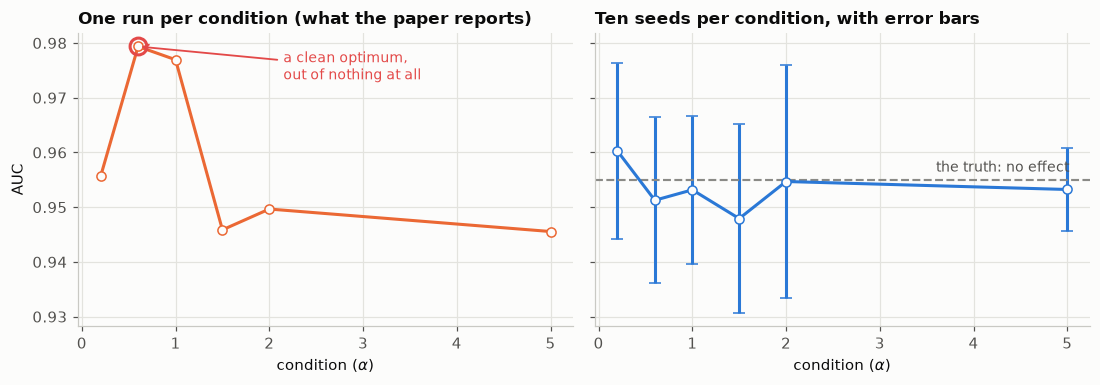

In [11]:
# --- The same experiment with 10 seeds, and error bars ---------------------
reps = TRUE_AUC + SIGMA * sim.standard_normal((10, len(ALPHA_GRID)))
mean10, sd10 = reps.mean(0), reps.std(0, ddof=1)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)

ax = axes[0]
ax.plot(ALPHA_GRID, one_run, "o-", color=C["orange"], ms=6, mfc="#fcfcfb")
ax.plot([ALPHA_GRID[one_run.argmax()]], [one_run.max()], "o", color=C["red"], ms=11,
        mfc="none", mew=2)
ax.annotate("a clean optimum,\nout of nothing at all",
            xy=(ALPHA_GRID[one_run.argmax()], one_run.max()),
            xytext=(2.15, one_run.max() - 0.006), fontsize=9, color=C["red"],
            arrowprops=dict(arrowstyle="->", color=C["red"], lw=1.2))
ax.set_title("One run per condition (what the paper reports)")
ax.set_xlabel("condition ($\\alpha$)"); ax.set_ylabel("AUC")

ax = axes[1]
ax.errorbar(ALPHA_GRID, mean10, yerr=sd10, fmt="o-", color=C["blue"], ms=6,
            mfc="#fcfcfb", capsize=4)
ax.axhline(TRUE_AUC, color=C["grey"], lw=1.4, ls="--")
ax.text(3.6, TRUE_AUC + 0.0015, "the truth: no effect", fontsize=9, color="#52514e")
ax.set_title("Ten seeds per condition, with error bars")
ax.set_xlabel("condition ($\\alpha$)")

plt.tight_layout(); plt.show()

**Figure 4.** Both panels are the **same underlying reality**: six identical
conditions. Left, with one run each, you get a peak, a story, and a
recommended operating point. Right, with ten runs and error bars, you get the
truth — which is that there is nothing there.

The apparent spread in the left panel is of the same order as the published α
effect. That is not an accusation — it is the whole reason error bars exist.

**What the reader should take away:** distrust every unreplicated sweep you ever
read — including the ones in this repository. Notebook 04 shows the follow-on
project applying this rule to itself, with ≥10 seeds and a paired test on every
claim, and recording a floor it failed to clear.

One caveat, so this is not overstated: this simulation shows that a single-run
sweep *can* manufacture a peak of exactly the published size. It does not show
that the published peak *was* noise. Nothing can show that, which is the problem.

The seed is pinned at 11 so the notebook is reproducible, and this particular
draw happens to peak at α = 0.6. **That is a coincidence of the seed, not a
construction** — and the honest way to show it is to stop looking at one draw.
Run the same no-effect experiment a thousand times and ask two questions: where
does the apparent optimum land, and how big does the apparent spread get?

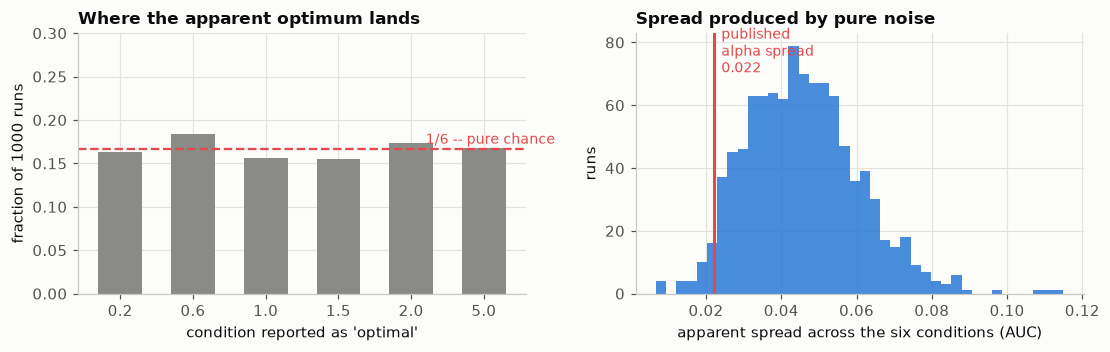

median apparent spread under NO effect : 0.0448
published alpha spread                 : 0.0220
fraction of no-effect runs whose spread is at least as large: 96.7%


In [12]:
# --- The same no-effect experiment, 1000 times -----------------------------
sim2 = np.random.default_rng(2024)
draws = TRUE_AUC + SIGMA * sim2.standard_normal((1000, len(ALPHA_GRID)))
argmax_counts = np.bincount(draws.argmax(1), minlength=len(ALPHA_GRID))
spreads = draws.max(1) - draws.min(1)

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.3))

ax = axes[0]
ax.bar([str(a) for a in ALPHA_GRID], argmax_counts / 1000, color=C["grey"], width=0.6)
ax.axhline(1 / len(ALPHA_GRID), color=C["red"], lw=1.5, ls="--")
ax.text(4.2, 1 / len(ALPHA_GRID) + 0.006, "1/6 -- pure chance", color=C["red"], fontsize=9)
ax.set_ylim(0, 0.30)
ax.set_xlabel("condition reported as 'optimal'"); ax.set_ylabel("fraction of 1000 runs")
ax.set_title("Where the apparent optimum lands")

ax = axes[1]
ax.hist(spreads, bins=40, color=C["blue"], alpha=0.85)
ax.axvline(paper_spread, color=C["red"], lw=2)
ax.text(paper_spread + 0.001, ax.get_ylim()[1] * 0.85,
        f" published\n alpha spread\n {paper_spread:.3f}", color=C["red"], fontsize=9)
ax.set_xlabel("apparent spread across the six conditions (AUC)")
ax.set_ylabel("runs")
ax.set_title("Spread produced by pure noise")

plt.tight_layout(); plt.show()

frac = float((spreads >= paper_spread).mean())
print(f"median apparent spread under NO effect : {np.median(spreads):.4f}")
print(f"published alpha spread                 : {paper_spread:.4f}")
print(f"fraction of no-effect runs whose spread is at least as large: {frac:.1%}")

**Figure 5.** Left: with no true effect, each of the six conditions is declared
optimal about one time in six. The α = 0.6 peak in the previous figure was that
lottery, once. Right: the spread that pure noise produces at this σ, against the
published α spread of 0.022. A large fraction of no-effect runs produce a spread
at least that big.

This does not say the published peak *was* noise — nothing can say that, which is
the complaint. It says a design with one run per condition **cannot tell the
difference**, and the difference is the entire claim.

**Two caveats a careful reader will raise, and should.**

1. *"Noise typically produces a spread of 0.045, which is larger than the
   published 0.022 — doesn't that suggest the paper's pipeline is quieter than
   yours?"* It might. σ = 0.0179 is the seed σ measured **on the replication**,
   and the paper reports no σ of its own. If its pipeline were substantially more
   stable, its 0.022 would mean more. There is no way to check, because the
   number was never reported — which is the same complaint in a different place.
2. *"You are simulating Gaussian noise, and real pipeline noise is not
   Gaussian."* True. The simulation is an illustration of a mechanism, not an
   estimate of anything. The load-bearing evidence for F3 is the **measured**
   sweep in §3: 0.0098 of spread against 0.0179 of measured σ.

---

## 5. F4 — ablate against your own novelty

The entropia paper's contribution is **not** the Rényi entropy. It is the **time
weighting** (its Eqs. 3–4) that turns a static entropy into a dynamic
time-weighted one — DTWRE. So the ablation that isolates the contribution is
DTWRE against **static Rényi**, everything else held fixed.

Here is what the replication measured, over 10 seeds with a paired Wilcoxon test.

*(A **paired** test compares the two methods seed by seed and tests the
differences. Pairing removes the seed's own variance from the comparison, which
is why it can detect smaller effects than an unpaired test on the same data.)*

In [13]:
# --- Verified constants: the significance tests ----------------------------
# Source: results/significance_auc.json -- 10 seeds (42-51), paired Wilcoxon.
# EVIDENCE-INDEX.md sect. 5.
METHODS = pd.DataFrame([
    ("Node2vec",        0.7897035013155231, 0.0201424),
    ("Node PageRank",   0.8213266545233758, 0.0194789),
    ("Node Degree",     0.8229659987856709, 0.0191883),
    ("Rényi (static)",  0.8369156041287189, 0.0144662),
    ("DTWRE",           0.8403916211293261, 0.0179144),
], columns=["method", "mean_auc", "sd_auc"])

PAIRED = pd.DataFrame([
    ("Node2vec",       0.0507, 0.0184, "10/10", 0.0020, True),
    ("Node PageRank",  0.0191, 0.0244,  "8/10", 0.0371, True),
    ("Node Degree",    0.0174, 0.0251,  "8/10", 0.0488, True),
    ("Rényi (static)", 0.0035, 0.0221,  "6/10", 0.625,  False),
], columns=["DTWRE vs", "mean_diff", "sd_diff", "wins", "wilcoxon_p", "significant"])
PAIRED["is_the_ablation"] = ["", "", "", "<-- THIS ONE"]

print("CollegeMsg, 10 seeds. Metric AUC (chance 0.5).\n")
print(METHODS.round(4).to_string(index=False))
print()
print(PAIRED.to_string(index=False))

CollegeMsg, 10 seeds. Metric AUC (chance 0.5).

        method  mean_auc  sd_auc
      Node2vec    0.7897  0.0201
 Node PageRank    0.8213  0.0195
   Node Degree    0.8230  0.0192
Rényi (static)    0.8369  0.0145
         DTWRE    0.8404  0.0179

      DTWRE vs  mean_diff  sd_diff  wins  wilcoxon_p  significant is_the_ablation
      Node2vec     0.0507   0.0184 10/10      0.0020         True                
 Node PageRank     0.0191   0.0244  8/10      0.0371         True                
   Node Degree     0.0174   0.0251  8/10      0.0488         True                
Rényi (static)     0.0035   0.0221  6/10      0.6250        False    <-- THIS ONE


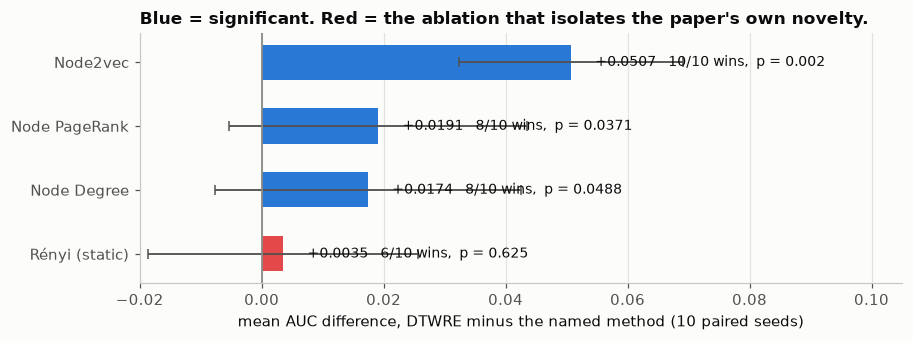

In [14]:
# --- Chart: DTWRE beats everything except the comparison that matters ------
fig, ax = plt.subplots(figsize=(8.4, 3.2))
d = PAIRED.iloc[::-1]
cols = [C["red"] if not s else C["blue"] for s in d["significant"]]
ax.barh(d["DTWRE vs"], d["mean_diff"], xerr=d["sd_diff"], color=cols, height=0.55,
        error_kw=dict(ecolor="#52514e", capsize=3, lw=1.2))
ax.axvline(0, color=C["grey"], lw=1.2)
for y, (v, w, p) in enumerate(zip(d["mean_diff"], d["wins"], d["wilcoxon_p"])):
    ax.text(v + 0.004, y, f"{v:+.4f}   {w} wins,  p = {p}", va="center", fontsize=9)
ax.set_xlim(-0.02, 0.105)
ax.set_xlabel("mean AUC difference, DTWRE minus the named method (10 paired seeds)")
ax.set_title("Blue = significant. Red = the ablation that isolates the paper's own novelty.")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Figure 6.** DTWRE beats every baseline that is **not** its own ablation, and
does not beat its own ablation. **6 wins in 10 is what a coin does.**

The published version of the same comparison is 0.9742 vs 0.9487 — a gap of
**0.0255** — reported from a single run, against a measured σ of 0.0179 on that
comparison. Which is Figure 4 again.

Let us put a number on "6 in 10 is what a coin does", since it is the kind of
thing that is easy to nod along to and hard to feel.

In [15]:
# --- How surprising is 6 wins in 10, if the two methods are identical? -----
from scipy.stats import binom
k, n = 6, 10
print(f"If DTWRE and static Rényi were identical, wins would be a fair coin.")
print(f"  P(exactly {k} wins in {n})   = {binom.pmf(k, n, 0.5):.4f}")
print(f"  P(at least {k} wins in {n})  = {binom.sf(k - 1, n, 0.5):.4f}")
print(f"  the reported Wilcoxon p      = 0.625")
print()
print("For contrast, the same calculation for the 10/10 result against Node2vec:")
print(f"  P(at least 10 wins in 10)    = {binom.sf(9, n, 0.5):.4f}")

If DTWRE and static Rényi were identical, wins would be a fair coin.
  P(exactly 6 wins in 10)   = 0.2051
  P(at least 6 wins in 10)  = 0.3770
  the reported Wilcoxon p      = 0.625

For contrast, the same calculation for the 10/10 result against Node2vec:
  P(at least 10 wins in 10)    = 0.0010


**The structural lesson, which outlives this paper.** Beating unrelated baselines
is easy: Node2Vec, PageRank and degree are not what the paper contributed, and
DTWRE beats all three. The **only** comparison that tests a contribution is the
one that removes exactly the contribution and changes nothing else. Here that
comparison exists, is cheap, and comes out at p = 0.625.

*This is the cleanest statement of the problem in the whole series: the paper's
design could not have determined whether its central mechanism contributes 0.004
or 0.04.*

### And the corroborating result: λ *does* do something

It matters that this is not a claim that nothing in the paper works. The **other**
knob — λ, the exponential time-decay constant in the same equation — moves the
result by about 3 σ.

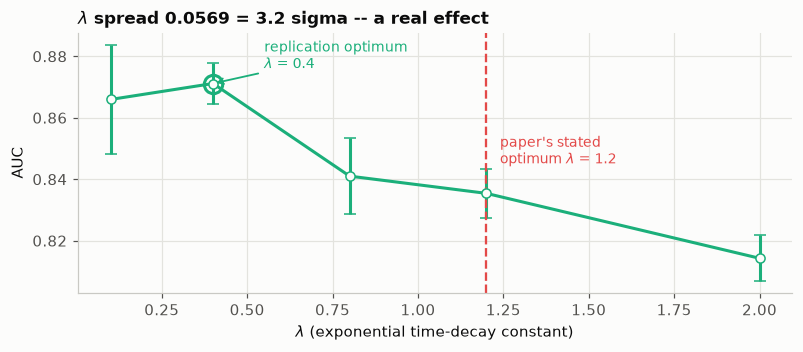

lambda spread 0.0569 = 3.17 sigma  (a real effect)
alpha  spread 0.0098 = 0.55 sigma  (inside noise)


In [16]:
# --- Verified constants: the lambda sweep ----------------------------------
# Source: results/lambda_sweep.json. EVIDENCE-INDEX.md sect. 4.
LAMBDA = pd.DataFrame([
    (0.1, 0.8659515617621264, 0.0177312305625150),
    (0.4, 0.8711461917290696, 0.0067583629771958),
    (0.8, 0.8410072185117722, 0.0123704228059493),
    (1.2, 0.8354078121837686, 0.0078837275687894),
    (2.0, 0.8142751130000674, 0.0074254599520413),
], columns=["lambda", "auc", "auc_std"])
lam_spread = LAMBDA.auc.max() - LAMBDA.auc.min()     # 0.0568710787290022

fig, ax = plt.subplots(figsize=(7.4, 3.3))
ax.errorbar(LAMBDA["lambda"], LAMBDA.auc, yerr=LAMBDA.auc_std, fmt="o-",
            color=C["aqua"], ms=6, mfc="#fcfcfb", capsize=4)
best = LAMBDA.loc[LAMBDA.auc.idxmax()]
ax.plot([best["lambda"]], [best.auc], "o", color=C["aqua"], ms=12, mfc="none", mew=2)
ax.annotate(f"replication optimum\n$\\lambda$ = {best['lambda']}",
            xy=(best["lambda"], best.auc), xytext=(0.55, 0.876), fontsize=9,
            color=C["aqua"], arrowprops=dict(arrowstyle="->", color=C["aqua"], lw=1.2))
ax.axvline(1.2, color=C["red"], lw=1.5, ls="--")
ax.text(1.24, 0.845, "paper's stated\noptimum $\\lambda$ = 1.2", fontsize=9, color=C["red"])
ax.set_xlabel("$\\lambda$ (exponential time-decay constant)"); ax.set_ylabel("AUC")
ax.set_title(f"$\\lambda$ spread {lam_spread:.4f} = {lam_spread/SEED_SIGMA:.1f} sigma -- a real effect")
plt.tight_layout(); plt.show()

print(f"lambda spread {lam_spread:.4f} = {lam_spread/SEED_SIGMA:.2f} sigma  (a real effect)")
print(f"alpha  spread {spread:.4f} = {spread/SEED_SIGMA:.2f} sigma  (inside noise)")

**Figure 7.** The time-decay constant λ moves AUC by 0.0568 — about 3 σ, an
effect that is clearly real. But the replication's optimum is **λ = 0.4** and the
paper's stated optimum is **λ = 1.2**, which sits near the bottom of the range
measured here.

So the honest summary of the entropia paper's mechanism is: *the time weighting
matters, the order α does not, and the reported operating point for the one that
matters is not where the optimum is.*

## What this licenses

- On CollegeMsg link prediction, α ∈ [0.2, 5] moves AUC by **0.0098** against a measured seed σ of **0.0179**. α is not a useful knob on this substrate.
- The paper's own reported α effect (**0.022**) is 1.2 σ and was measured without seeds, repetitions or error bars.
- DTWRE against static Rényi — the ablation that isolates the paper's contribution — is **+0.0035, 6/10 wins, p = 0.625**: not significant.
- λ *is* significant (0.0568 ≈ 3 σ), and the replication's optimum (λ = 0.4) is not the paper's stated one (λ = 1.2).
- The general methodological points: measure the noise floor before reading a sweep, and ablate against your own novelty rather than against unrelated baselines.

## What this does NOT license

- *"Rényi entropy is useless."* This is one substrate — neighbourhood degree distributions with a handful of points — inside one link-prediction pipeline. The family is not on trial; this application of it is.
- *"α never matters."* Notebook 04 applies the same family to inter-arrival distributions with hundreds to thousands of points per account and gets a **different** answer. F3 is a finding about a **substrate**.
- *"The published α peak was noise."* §4 shows a single-run sweep **can** manufacture a peak of that size. It cannot show that this one did — and neither can anything else, which is precisely the complaint.
- *"The time weighting does not work."* λ moves the result by about 3 σ. What is unsupported is the specific DTWRE-over-static-Rényi gap, and the stated operating point.
- Any claim about the paper's Weibo results. The corpus it used is under-specified and the replication had to substitute a different subset (`docs/DISCREPANCIES.md` §9), so those numbers are not comparable.

---

**Next:** [03 — protocol and floors](03-protocol-and-floors.ipynb), where a
four-line classifier that ignores its input beats eight published rows.